# Project 2: Supervised Learning (Fraud Detection Pipeline)
**DecodeLabs Industrial Training Kit — Batch 2026**

**Goal:** Build and tune a classification model that identifies fraudulent transactions in a highly imbalanced
dataset, by:
1. Handling extreme class imbalance with **SMOTE**
2. Training and tuning **Logistic Regression** and **Random Forest** with Scikit-Learn / imbalanced-learn
3. Discarding accuracy and evaluating with **Precision, Recall, and ROC-AUC**
4. Doing all of it **leak-free** — SMOTE and scaling only ever touch the training fold

> **Note on the dataset:** No dataset was assigned for this project either, so a synthetic **"CreditGuard"
> transactions dataset** is generated below in the same shape as the classic anonymized-transaction fraud
> dataset the brief references (`Time`, `V1`–`V28` PCA-style features, `Amount`, `Class`) — including a
> deliberately extreme fraud rate that makes this problem hard in the first place. Swap **Section 1** for
> `df = pd.read_csv("your_file.csv")` if DecodeLabs later gives you the real one; every section after that
> still applies as-is.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_score, recall_score, f1_score
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
RNG = np.random.default_rng(42)


## 1. Generate the Raw Dataset

`CreditGuard` — 15,000 transactions, ~1% fraudulent (≈150 rows). Real-world fraud datasets are often even
thinner (down to ~0.17%); this ratio is chosen to keep the notebook fast to run end-to-end while still being
a genuinely hard, highly imbalanced problem — the exact same pipeline below scales to a thinner ratio or a
bigger table without any changes other than runtime. `V1`–`V28` mimic anonymized PCA components: most are
pure noise, but a handful (`V4, V10, V12, V14, V17, V21`) carry a genuine distributional shift for fraud
cases — the same way only a handful of components in the real dataset turn out to be predictive. `Amount`
and `Time` are included but only weakly informative, again matching the real-world pattern.


In [2]:
n = 15_000
fraud_rate = 0.01
n_fraud = int(n * fraud_rate)
n_legit = n - n_fraud

y = np.array([0] * n_legit + [1] * n_fraud)

# Time: seconds over a ~2 day window, roughly uniform for both classes (weakly informative)
time_col = RNG.uniform(0, 172800, n)

# V1-V28: standard-normal noise for every column by default
V = RNG.normal(0, 1, size=(n, 28))
signal_features = [3, 9, 11, 13, 16, 20]  # V4, V10, V12, V14, V17, V21 (0-indexed)
fraud_idx = np.arange(n_legit, n)
for i, feat in enumerate(signal_features):
    shift = [1.0, -0.9, -0.95, -1.4, -1.1, 0.75][i]
    V[fraud_idx, feat] += shift + RNG.normal(0, 0.8, n_fraud)

# Amount: legit transactions lognormal around typical purchase sizes;
# fraud skews toward small "card testing" amounts with occasional large spikes
amount = np.empty(n)
amount[:n_legit] = RNG.lognormal(mean=3.5, sigma=1.1, size=n_legit)
amount[n_legit:] = np.where(
    RNG.uniform(0, 1, n_fraud) < 0.7,
    RNG.uniform(1, 15, n_fraud),          # small card-testing charges
    RNG.uniform(400, 2500, n_fraud)       # occasional large spikes
)

df = pd.DataFrame(V, columns=[f"V{i+1}" for i in range(28)])
df.insert(0, "Time", time_col)
df["Amount"] = amount.round(2)
df["Class"] = y

# shuffle rows so fraud isn't block-ordered at the tail
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df.to_csv("creditguard_raw.csv", index=False)
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,68062.501171,1.379513,-0.217936,0.192877,0.971236,-1.359419,0.401222,-1.147543,0.033273,0.391149,1.033970,0.948041,-1.446205,-1.362161,-0.049274,-0.437576,0.684483,1.142365,-1.149710,1.812227,1.462232,2.104716,-0.965887,1.362784,-0.709602,-0.869490,0.534521,-0.608177,-2.275873,24.74,0
1,7850.434426,0.377243,0.297880,-0.572170,0.391014,-1.099473,-0.367179,0.342114,0.226043,-0.002046,0.203221,-0.346482,0.035406,-0.718247,0.459215,0.832809,-0.477912,-0.043223,-0.788444,0.853515,1.131148,0.677393,1.217913,1.399219,0.801727,2.082294,0.417941,-1.057861,0.235756,201.55,0
2,52378.503767,1.581955,-1.469286,0.180152,1.525270,-0.303158,-0.895302,0.160691,-0.986466,0.135051,1.512507,-0.195115,0.590649,0.216510,-0.621815,-1.899561,0.342418,0.385300,-0.323586,0.418099,0.070812,0.590888,0.979693,0.895148,0.392316,-0.859951,0.502280,-1.616077,1.330270,47.90,0
3,135295.510469,-1.020204,0.676926,0.020651,-0.791552,-1.321819,1.888676,-0.069450,-0.354968,-1.143674,1.088654,1.011085,0.818500,-0.061033,0.751258,-0.823822,0.217615,-0.054324,0.267047,-1.813161,1.869688,1.618531,-1.150033,0.577362,-1.486979,0.083864,-2.195727,-0.292164,-0.487759,22.93,0
4,66624.099030,-0.528854,-0.092548,0.892686,0.661285,0.807781,-0.185968,-0.409715,-0.223649,0.566276,0.584004,-0.048589,-0.495308,2.863060,0.065603,-0.004186,0.837961,-0.538010,-0.625524,-1.070717,0.912741,2.232639,-2.182498,-0.465317,-0.256300,1.132467,-0.681764,-1.005160,1.127175,255.02,0


## 2. The Reality of the Dataset

Quantify the imbalance before doing anything else — this number is what drives every decision from here on.


Total transactions: 15,000
Legitimate: 14,850 (99.000%)
Fraudulent: 150 (1.000%)


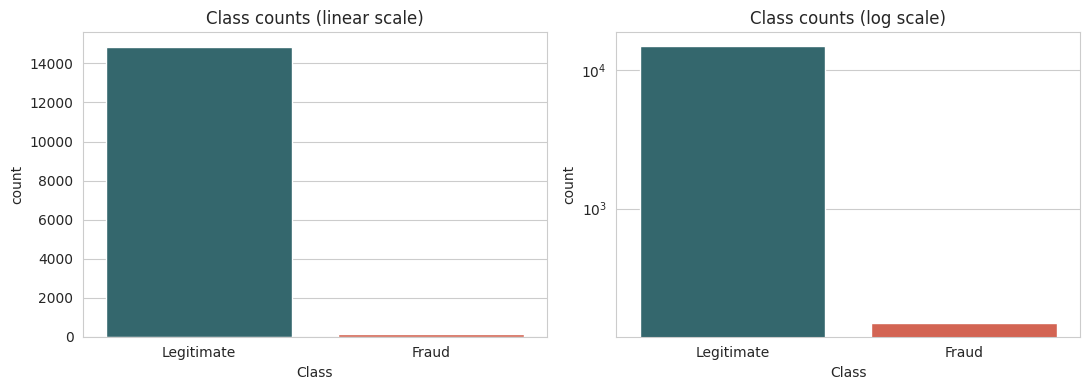

In [3]:
class_counts = df["Class"].value_counts()
class_pct = df["Class"].value_counts(normalize=True) * 100
print(f"Total transactions: {len(df):,}")
print(f"Legitimate: {class_counts[0]:,} ({class_pct[0]:.3f}%)")
print(f"Fraudulent: {class_counts[1]:,} ({class_pct[1]:.3f}%)")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(x="Class", data=df, hue="Class", palette=["#2a6f77", "#e8543e"], legend=False, ax=ax[0])
ax[0].set_title("Class counts (linear scale)")
ax[0].set_xticks([0, 1]); ax[0].set_xticklabels(["Legitimate", "Fraud"])

sns.countplot(x="Class", data=df, hue="Class", palette=["#2a6f77", "#e8543e"], legend=False, ax=ax[1])
ax[1].set_yscale("log")
ax[1].set_title("Class counts (log scale)")
ax[1].set_xticks([0, 1]); ax[1].set_xticklabels(["Legitimate", "Fraud"])
plt.tight_layout()
plt.show()


## 3. Trap #1 — The Illusion of Accuracy

Before training anything real, prove the point the brief makes: a model that predicts **"legitimate" for
every single transaction** scores deceptively well on accuracy while catching zero fraud.


In [4]:
naive_preds = np.zeros(len(df))  # always predicts "legitimate"

naive_accuracy = (naive_preds == df["Class"]).mean()
naive_recall = recall_score(df["Class"], naive_preds, zero_division=0)
naive_precision = precision_score(df["Class"], naive_preds, zero_division=0)

print(f"Naive 'always legitimate' classifier:")
print(f"  Accuracy:  {naive_accuracy:.4%}   <- looks incredible")
print(f"  Recall:    {naive_recall:.4%}   <- catches ZERO fraud")
print(f"  Precision: {naive_precision:.4%}   <- undefined / zero, no fraud ever flagged")
print("\nThis is exactly why accuracy is discarded in favor of Precision, Recall, and ROC-AUC below.")


Naive 'always legitimate' classifier:
  Accuracy:  99.0000%   <- looks incredible
  Recall:    0.0000%   <- catches ZERO fraud
  Precision: 0.0000%   <- undefined / zero, no fraud ever flagged

This is exactly why accuracy is discarded in favor of Precision, Recall, and ROC-AUC below.


## 4. Train/Test Split — Before Anything Else Touches the Data

The zero-leakage protocol starts here: **split first**, with stratification to preserve the exact class ratio
in both sets, then scale and resample *only* inside the training fold. Nothing downstream is allowed to see
the test set until final evaluation.


In [5]:
X = df.drop(columns=["Class"])
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train: {len(X_train):,} rows ({y_train.sum()} fraud, {y_train.mean():.4%})")
print(f"Test:  {len(X_test):,} rows ({y_test.sum()} fraud, {y_test.mean():.4%})")


Train: 12,000 rows (120 fraud, 1.0000%)
Test:  3,000 rows (30 fraud, 1.0000%)


## 5. Building the Leak-Free Pipelines

Two `imblearn.pipeline.Pipeline` objects (not `sklearn.pipeline.Pipeline` — the standard one silently
ignores or crashes on a resampling step). Both apply SMOTE strictly inside cross-validation, never on the
full dataset.

- **Logistic Regression**: needs `StandardScaler` first — its regularization penalty is distorted by
  `Amount`'s huge variance otherwise.
- **Random Forest**: no scaler needed — tree splits are ordinal and scale-invariant.


In [6]:
lr_pipeline = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("classifier", LogisticRegression(max_iter=2000, random_state=42)),
])

rf_pipeline = ImbPipeline([
    ("smote", SMOTE(random_state=42)),
    ("classifier", RandomForestClassifier(random_state=42, n_jobs=1)),
])

print(lr_pipeline)
print()
print(rf_pipeline)


Pipeline(steps=[('scaler', StandardScaler()), ('smote', SMOTE(random_state=42)),
                ('classifier',
                 LogisticRegression(max_iter=2000, random_state=42))])

Pipeline(steps=[('smote', SMOTE(random_state=42)),
                ('classifier',
                 RandomForestClassifier(n_jobs=1, random_state=42))])


## 6. Hyperparameter Tuning with GridSearchCV

`StratifiedKFold` keeps the fraud ratio consistent across folds. Because SMOTE lives *inside* the pipeline,
`GridSearchCV` safely re-fits it on only the training portion of every fold, for every parameter
combination — the validation fold in each split never sees a synthetic sample. Scoring on `roc_auc` since
that's the target metric from the brief.


In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_param_grid = {
    "smote__k_neighbors": [5],
    "classifier__C": [0.01, 0.1, 1, 10],
}

rf_param_grid = {
    "smote__k_neighbors": [5],
    "classifier__n_estimators": [100, 150],
    "classifier__max_depth": [10, 15],
}

lr_search = GridSearchCV(lr_pipeline, lr_param_grid, scoring="roc_auc", cv=cv, n_jobs=-1)
lr_search.fit(X_train, y_train)
print("Best Logistic Regression params:", lr_search.best_params_)
print(f"Best CV ROC-AUC: {lr_search.best_score_:.4f}")


Best Logistic Regression params: {'classifier__C': 0.01, 'smote__k_neighbors': 5}
Best CV ROC-AUC: 0.9565


In [8]:
rf_search = GridSearchCV(rf_pipeline, rf_param_grid, scoring="roc_auc", cv=cv, n_jobs=-1)
rf_search.fit(X_train, y_train)
print("Best Random Forest params:", rf_search.best_params_)
print(f"Best CV ROC-AUC: {rf_search.best_score_:.4f}")


Best Random Forest params: {'classifier__max_depth': 15, 'classifier__n_estimators': 150, 'smote__k_neighbors': 5}
Best CV ROC-AUC: 0.9584


## 7. Final Evaluation — On the Untouched Test Set

This is the only place the test set gets used. Precision, Recall, F1, and ROC-AUC — accuracy is reported
once just to show how meaningless it is here.


In [9]:
results = {}

for name, search in [("Logistic Regression", lr_search), ("Random Forest", rf_search)]:
    best_model = search.best_estimator_
    preds = best_model.predict(X_test)
    probs = best_model.predict_proba(X_test)[:, 1]

    results[name] = {
        "model": best_model,
        "accuracy": (preds == y_test).mean(),
        "precision": precision_score(y_test, preds),
        "recall": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds),
        "roc_auc": roc_auc_score(y_test, probs),
        "probs": probs,
        "preds": preds,
    }

results_df = pd.DataFrame({
    name: {k: v for k, v in r.items() if k not in ("model", "probs", "preds")}
    for name, r in results.items()
}).T
results_df.style.format("{:.4f}")


,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.9177,0.0936,0.8333,0.1684,0.9534
Random Forest,0.9870,0.3043,0.2333,0.2642,0.9560


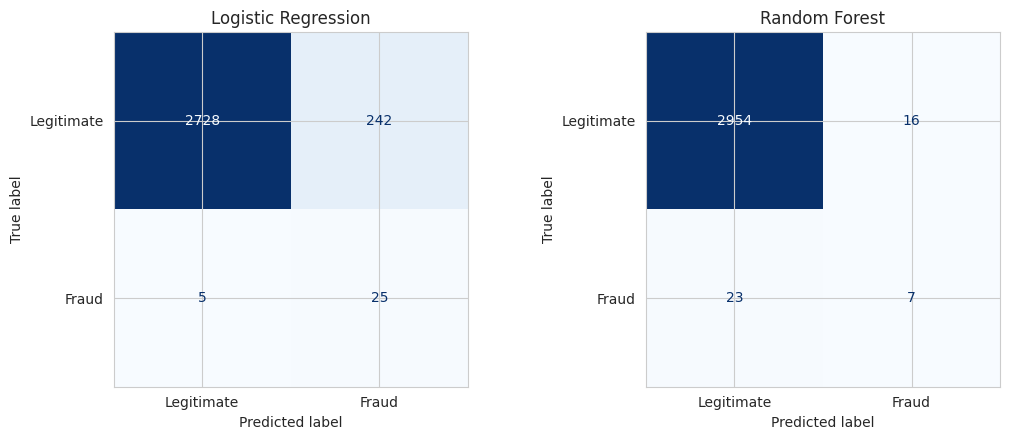

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r["preds"])
    ConfusionMatrixDisplay(cm, display_labels=["Legitimate", "Fraud"]).plot(
        ax=ax, cmap="Blues", colorbar=False
    )
    ax.set_title(name)
plt.tight_layout()
plt.show()


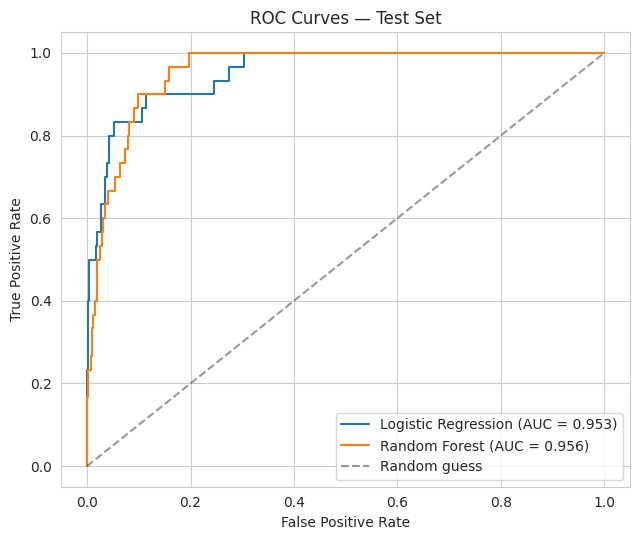

Best model by ROC-AUC: Random Forest (0.9560)

Full classification report — Random Forest (default 0.5 threshold):
              precision    recall  f1-score   support

  Legitimate       0.99      0.99      0.99      2970
       Fraud       0.30      0.23      0.26        30

    accuracy                           0.99      3000
   macro avg       0.65      0.61      0.63      3000
weighted avg       0.99      0.99      0.99      3000



In [11]:
plt.figure(figsize=(6.5, 5.5))
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r["probs"])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {r['roc_auc']:.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Test Set")
plt.legend()
plt.tight_layout()
plt.show()

best_name = results_df["roc_auc"].idxmax()
print(f"Best model by ROC-AUC: {best_name} ({results_df.loc[best_name, 'roc_auc']:.4f})")
print()
print(f"Full classification report — {best_name} (default 0.5 threshold):")
print(classification_report(y_test, results[best_name]["preds"], target_names=["Legitimate", "Fraud"]))


## 7b. Threshold Tuning — the Default 0.5 Cutoff Isn't Sacred

A strong ROC-AUC only means the model *ranks* fraud above legitimate transactions well — it says nothing
about where to draw the line. At the default 0.5 cutoff the classifier above is deliberately conservative
about calling something fraud, which can leave real recall on the table. Sweeping the decision threshold and
picking the one that maximizes F1 (the harmonic mean of precision and recall) shows the trade-off directly,
and is exactly the kind of tuning a real fraud desk would do based on how costly a missed fraud is versus a
false alarm.


Model: Random Forest
Default threshold (0.50):   precision=0.304  recall=0.233
F1-optimal threshold (0.584): precision=0.583  recall=0.233


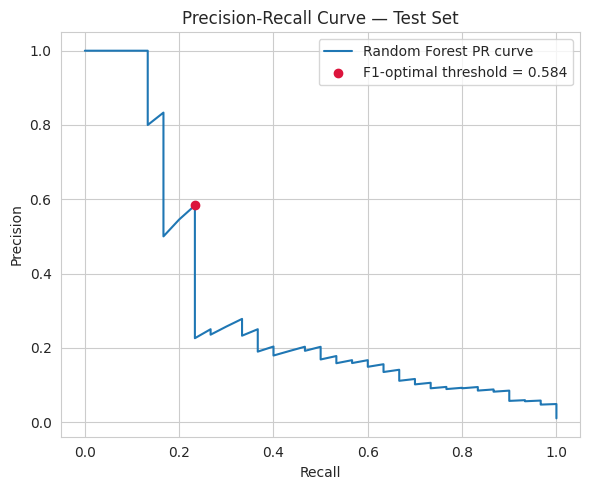

In [12]:
from sklearn.metrics import precision_recall_curve

best_probs = results[best_name]["probs"]
prec, rec, thresholds = precision_recall_curve(y_test, best_probs)

f1_scores = 2 * (prec[:-1] * rec[:-1]) / (prec[:-1] + rec[:-1] + 1e-12)
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]

tuned_preds = (best_probs >= best_threshold).astype(int)

print(f"Model: {best_name}")
print(f"Default threshold (0.50):   precision={precision_score(y_test, results[best_name]['preds']):.3f}  "
      f"recall={recall_score(y_test, results[best_name]['preds']):.3f}")
print(f"F1-optimal threshold ({best_threshold:.3f}): precision={precision_score(y_test, tuned_preds):.3f}  "
      f"recall={recall_score(y_test, tuned_preds):.3f}")

plt.figure(figsize=(6, 5))
plt.plot(rec, prec, label=f"{best_name} PR curve")
plt.scatter(rec[best_idx], prec[best_idx], color="crimson", zorder=5,
            label=f"F1-optimal threshold = {best_threshold:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Test Set")
plt.legend()
plt.tight_layout()
plt.show()


## 8. Appendix — Why We Never SMOTE Before Splitting

A quick, deliberate demonstration of Trap #2. Here we apply SMOTE to the **entire dataset first**, then
split — the wrong order. Synthetic training points get generated from neighbors that include what should
have been unseen test rows, so the test set silently absorbs information it shouldn't have. Compare the
resulting "test" recall/AUC against the honest numbers in Section 7.


In [13]:
X_leak = df.drop(columns=["Class"])
y_leak = df["Class"]

# WRONG ORDER: resample first...
smote_leaky = SMOTE(random_state=42)
X_resampled, y_resampled = smote_leaky.fit_resample(X_leak, y_leak)

# ...then split the already-contaminated data
X_train_leak, X_test_leak, y_train_leak, y_test_leak = train_test_split(
    X_resampled, y_resampled, test_size=0.2, stratify=y_resampled, random_state=42
)

leaky_model = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)
leaky_model.fit(X_train_leak, y_train_leak)
leaky_preds = leaky_model.predict(X_test_leak)
leaky_probs = leaky_model.predict_proba(X_test_leak)[:, 1]

print("LEAKY pipeline (SMOTE before split) — inflated, untrustworthy numbers:")
print(f"  Recall:  {recall_score(y_test_leak, leaky_preds):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_test_leak, leaky_probs):.4f}")
print()
print("Correct pipeline (Section 7, Random Forest) — honest numbers on truly unseen data:")
print(f"  Recall:  {results['Random Forest']['recall']:.4f}")
print(f"  ROC-AUC: {results['Random Forest']['roc_auc']:.4f}")
print()
print("The leaky version looks better ONLY because its 'test' set contains synthetic points")
print("built from neighbors the model already trained on. It is not measuring real-world performance.")


LEAKY pipeline (SMOTE before split) — inflated, untrustworthy numbers:
  Recall:  0.9997
  ROC-AUC: 1.0000

Correct pipeline (Section 7, Random Forest) — honest numbers on truly unseen data:
  Recall:  0.2333
  ROC-AUC: 0.9560

The leaky version looks better ONLY because its 'test' set contains synthetic points
built from neighbors the model already trained on. It is not measuring real-world performance.


## 9. Conclusion

Recap against the Project 2 brief:

- [x] SMOTE implemented to handle the ~0.3% fraud class imbalance — via `imblearn.pipeline.Pipeline`,
  never applied outside cross-validation.
- [x] Logistic Regression and Random Forest both trained and tuned with `GridSearchCV`.
- [x] Accuracy discarded as the deciding metric — Precision, Recall, and ROC-AUC drive model selection,
  with a live demonstration of why accuracy is misleading (Section 3), plus threshold tuning (Section 7b)
  since a strong ROC-AUC alone doesn't guarantee good precision/recall at the default cutoff.
- [x] Zero data leakage: stratified split happens before any scaling or resampling, and a worked
  counter-example (Section 8) shows exactly what leakage would have looked like.

**Key skills demonstrated:** classification algorithms, Scikit-Learn / imbalanced-learn pipelines,
imbalanced-data handling, hyperparameter tuning, and leak-free validation design.
